<a href="https://colab.research.google.com/github/HnhanBk415/zfs-clip-image-captioning/blob/main/notebook/flickr8k_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [198]:
from config import *

In [199]:
# Cấu hình chiến lược
STRICT_CAPTIONS_PER_IMAGE = 5  # Bắt buộc cứng đúng 5 captions/ảnh
MIN_WORD_COUNT = 2              # Số từ tối thiểu trong mỗi caption

In [200]:
# Khởi tạo cây thư mục
setup_directories()

# Tải KaggleHub
dataset_path = kagglehub.dataset_download("adityajn105/flickr8k")
IMAGES_DIR = os.path.join(dataset_path, "Images")
CAPTIONS_FILE = os.path.join(dataset_path, "captions.txt")

# Dataset Preprocessing & Manifest Pipeline

## 1. DATASET EXPLORATION & RAW INTEGRITY CHECK

### 1.1. IMAGE FILES

In [201]:
all_image_files = sorted([
    file_name
    for file_name in os.listdir(IMAGES_DIR)
    if file_name.lower().endswith((".jpg", ".jpeg", ".png"))
])

image_files_set = set(all_image_files)

print(f"• Number of image files: {len(all_image_files):,}")

• Number of image files: 8,091


### 1.2. LOAD CAPTIONS & HANDLE DUPLICATES

In [202]:
df = pd.read_csv(CAPTIONS_FILE)
df.columns = df.columns.str.strip()

assert "image" in df.columns
assert "caption" in df.columns

# Thống kê trước khi loại bỏ trùng lặp
raw_pairs_count = len(df)
duplicate_pairs = df.duplicated(subset=["image", "caption"]).sum()

# Policy: Tự động loại bỏ các cặp (image, caption) trùng lặp hoàn toàn
if duplicate_pairs > 0:
    df = df.drop_duplicates(subset=["image", "caption"]).reset_index(drop=True)

print(f"• Raw caption pairs: {raw_pairs_count:,}")
print(f"• Duplicate (image, caption) pairs removed: {duplicate_pairs:,}")
print(f"• Clean caption pairs: {len(df):,}")
print(f"• Unique images in captions: {df['image'].nunique():,}")

• Raw caption pairs: 40,455
• Duplicate (image, caption) pairs removed: 10
• Clean caption pairs: 40,445
• Unique images in captions: 8,091


In [203]:
# Tìm các dòng trùng lặp trong dữ liệu gốc (trước khi drop)
raw_df = pd.read_csv(CAPTIONS_FILE)
raw_df.columns = raw_df.columns.str.strip()

# Lọc ra các dòng bị trùng hoàn toàn cả image và caption
dup_mask = raw_df.duplicated(subset=["image", "caption"], keep=False)
duplicates_df = raw_df[dup_mask].sort_values("image")

print(f" DANH SÁCH {len(duplicates_df)} DÒNG TRÙNG LẶP HOÀN TOÀN TRONG FILE GỐC:")
display(duplicates_df)

dup_image_ids = set(duplicates_df["image"].unique())
print(f"Số lượng ảnh bị ảnh hưởng bởi trùng lặp gốc: {len(dup_image_ids)} ảnh")

 DANH SÁCH 20 DÒNG TRÙNG LẶP HOÀN TOÀN TRONG FILE GỐC:


,image,caption
7467,2305437797_e6c3460190.jpg,A dog swimming with a stick in its mouth .
7468,2305437797_e6c3460190.jpg,A dog swimming with a stick in its mouth .
7826,2335619125_2e2034f2c3.jpg,A black dog is running through the snow .
7827,2335619125_2e2034f2c3.jpg,A black dog is running through the snow .
9466,2441629086_52f68eb316.jpg,A girl peers into a window .
9467,2441629086_52f68eb316.jpg,A girl peers into a window .
14020,2737729252_b3fd9c05b1.jpg,A girl is taking a picture of another girl in a park .
14021,2737729252_b3fd9c05b1.jpg,A girl is taking a picture of another girl in a park .
23917,3262075846_5695021d84.jpg,A group of men are playing rugby .
23916,3262075846_5695021d84.jpg,A group of men are playing rugby .


Số lượng ảnh bị ảnh hưởng bởi trùng lặp gốc: 10 ảnh


### 1.3. CAPTION COUNT PER IMAGE

In [204]:
caption_counts = df.groupby("image").size()

print(
    f"• Average captions/image: "
    f"{caption_counts.mean():.2f}"
)

print("\nCaption count distribution:")
print(caption_counts.value_counts().sort_index())

• Average captions/image: 5.00

Caption count distribution:
4      10
5    8081
Name: count, dtype: int64


### 1.4. RAW DATA QUALITY

In [205]:
print("\n--- RAW DATA QUALITY ---")

missing_values = df[["image", "caption"]].isnull().sum()

print("\nMissing values:")
print(missing_values)


empty_captions = df[df["caption"].fillna("").str.strip() == ""]

print(f"• Empty captions: {len(empty_captions)}")


caption_images_set = set(df["image"].dropna().unique())

missing_images = caption_images_set - image_files_set

images_without_captions = (image_files_set - caption_images_set)

print(
    f"• Caption references missing images: "
    f"{len(missing_images)}"
)

print(
    f"• Images without captions: "
    f"{len(images_without_captions)}"
)


--- RAW DATA QUALITY ---

Missing values:
image      0
caption    0
dtype: int64
• Empty captions: 0
• Caption references missing images: 0
• Images without captions: 0


### 1.5. VERIFY FLICKR8K 5-CAPTION STRUCTURE

In [206]:
images_with_exactly_5 = ((caption_counts == 5).sum())

images_not_5 = (caption_counts != 5).sum()

print(
    f"\n• Images with exactly 5 captions: "
    f"{images_with_exactly_5:,}"
)

print(
    f"• Images not having 5 captions: "
    f"{images_not_5:,}"
)


• Images with exactly 5 captions: 8,081
• Images not having 5 captions: 10


### 1.6. WORD-LEVEL CAPTION STATISTICS

In [207]:
caption_words = (df["caption"].fillna("").str.lower().str.split())

caption_lengths = caption_words.str.len()

all_words = [
    word
    for tokens in caption_words
    for word in tokens
]

vocab = Counter(all_words)

print("\n--- CAPTION STATISTICS ---")

print(
    f"• Caption length (words): "
    f"Min={caption_lengths.min()}, "
    f"Max={caption_lengths.max()}, "
    f"Avg={caption_lengths.mean():.2f}"
)

print(f"• Total word tokens: {len(all_words):,}")
print(f"• Vocabulary size: {len(vocab):,}")
print(f"• Top 10 words: {vocab.most_common(10)}")


--- CAPTION STATISTICS ---
• Caption length (words): Min=1, Max=38, Avg=11.78
• Total word tokens: 476,577
• Vocabulary size: 8,918
• Top 10 words: [('a', 62969), ('.', 36568), ('in', 18968), ('the', 18416), ('on', 10742), ('is', 9342), ('and', 8851), ('dog', 8132), ('with', 7764), ('man', 7264)]


### 1.7. VISUALIZATION

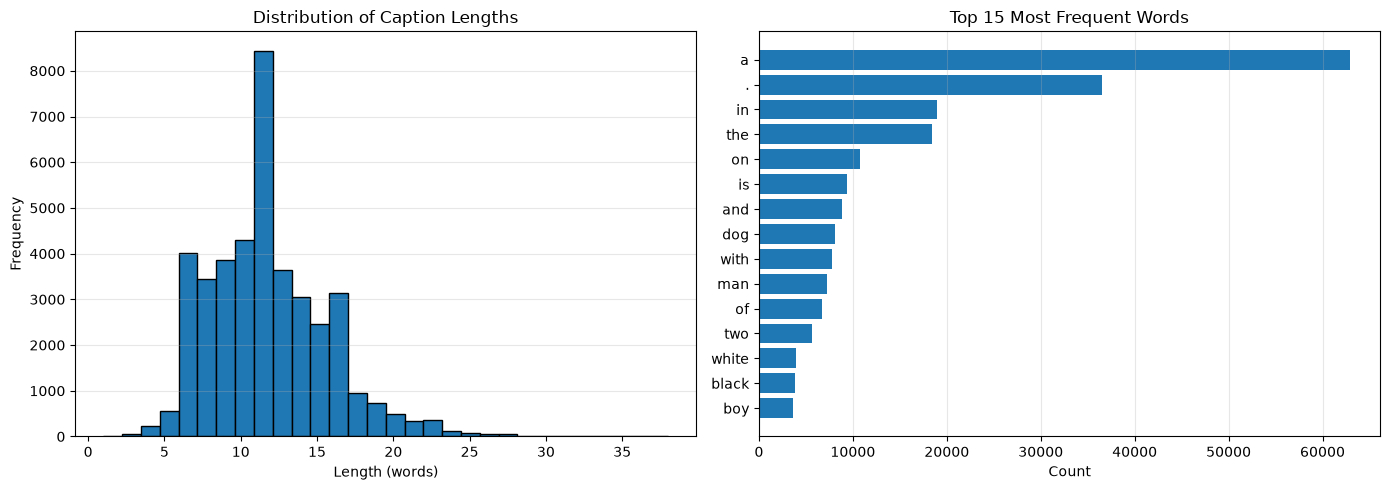

In [208]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(caption_lengths, bins=30, edgecolor="black")

axes[0].set_title("Distribution of Caption Lengths")
axes[0].set_xlabel("Length (words)")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis="y", alpha=0.3)


top_words = vocab.most_common(15)

words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

axes[1].barh(words[::-1], counts[::-1]
)

axes[1].set_title("Top 15 Most Frequent Words")
axes[1].set_xlabel("Count")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 2. PREPROCESS & VALIDATE DATA

### 2.1. MINIMAL CAPTION NORMALIZATION

In [209]:
def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize("NFC", text)

    text = text.strip()

    text = " ".join(text.split())

    return text

### 2.2 Caption Quality Audit

In [210]:
# 1. HÀM TẠO COMPARE KEY BẰNG CHUẨN HOÁ SÂU
def create_comparison_key(text: str) -> str:
    """Tạo key chuẩn hóa loại bỏ hoàn toàn dấu câu & khoảng trắng thừa để bắt trùng lặp"""
    if not isinstance(text, str):
        return ""
    # Chuyển về chữ thường
    text = text.lower()
    # Loại bỏ toàn bộ dấu câu
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Thu gọn khoảng trắng
    return ' '.join(text.split())


# 2. HÀM AUDIT MỘT CAPTION ĐƠN LẺ
def audit_caption(caption: str, min_words: int = 2) -> dict:
    if not isinstance(caption, str) or not caption.strip():
        return {"is_valid": False, "flags": ["EMPTY_OR_NULL"], "comp_key": ""}
    
    comp_key = create_comparison_key(caption)
    words = caption.strip().split()
    flags = []

    # Flag 1: Chỉ chứa dấu câu / rác rỗng
    if not comp_key:
        flags.append("ONLY_PUNCTUATION")

    # Flag 2: Mạo từ / Hư từ đơn lẻ (Ví dụ: 'A', 'a', 'the', 'an')
    if comp_key in ['a', 'an', 'the', 'in', 'on', 'at', 'is']:
        flags.append("ARTICLE_ONLY")

    # Flag 3: Meta-text / Nhãn ảnh lỗi từ annotator
    junk_patterns = [r'^(broken|corrupted|missing|no)\s+(image|photo|picture|file)$', r'^(n/a|none|null|unknown)$']
    for pattern in junk_patterns:
        if re.search(pattern, comp_key): # Đã import 're' nên sẽ không bị lỗi tại đây
            flags.append("META_TEXT_JUNK")
            break

    # Flag 4: Quá ngắn (Dưới ngưỡng word count)
    if len(words) < min_words:
        flags.append("TOO_SHORT")

    # Đánh giá validity: Invalid nếu mắc các lỗi rác nghiêm trọng
    invalid_flags = {"EMPTY_OR_NULL", "ONLY_PUNCTUATION", "ARTICLE_ONLY", "META_TEXT_JUNK"}
    is_valid = not any(f in invalid_flags for f in flags)

    return {
        "comp_key": comp_key,
        "word_count": len(words),
        "is_valid": is_valid,
        "flags": flags
    }

In [211]:
FLAG_TRANSLATIONS = {
    "EMPTY_OR_NULL": "Rỗng hoặc Null",
    "ONLY_PUNCTUATION": "Chỉ chứa dấu câu",
    "ARTICLE_ONLY": "Chỉ chứa mạo từ/từ đơn lẻ",
    "META_TEXT_JUNK": "Văn bản rác / Lỗi nhãn ảnh (Broken/Missing image...)",
    "TOO_SHORT": "Caption quá ngắn"
}

# Đọc file thô ban đầu
raw_df = pd.read_csv(CAPTIONS_FILE)
raw_df.columns = raw_df.columns.str.strip()

invalid_caption_logs = []

# Duyệt từng dòng để kiểm tra
for idx, row in raw_df.iterrows():
    img_id = row["image"]
    raw_cap = row["caption"]
    
    c_cap = clean_text(raw_cap)
    audit_res = audit_caption(c_cap, min_words=MIN_WORD_COUNT)
    
    # Nếu vi phạm điều kiện hợp lệ
    if not audit_res["is_valid"]:
        # Chuyển đổi các mã cờ lỗi sang Tiếng Việt
        vi_flags = [FLAG_TRANSLATIONS.get(f, f) for f in audit_res["flags"]]
        
        invalid_caption_logs.append({
            "Vị trí (Index)": idx,
            "Tên File Ảnh": img_id,
            "Caption Gốc": raw_cap,
            "Caption Chuẩn Hóa": c_cap,
            "Lý Do Vi Phạm (Flags)": ", ".join(vi_flags),
            "Số Từ": audit_res["word_count"]
        })

# Xuất kết quả
df_audit_violations = pd.DataFrame(invalid_caption_logs)

print(f"TỔNG SỐ CAPTION VI PHẠM LUẬT AUDIT: {len(df_audit_violations)} DÒNG\n")

if not df_audit_violations.empty:
    pd.set_option('display.max_colwidth', None) # Hiển thị đầy đủ text
    display(df_audit_violations)
else:
    print("Không có caption nào vi phạm luật Audit.")

TỔNG SỐ CAPTION VI PHẠM LUẬT AUDIT: 3 DÒNG



,Vị trí (Index),Tên File Ảnh,Caption Gốc,Caption Chuẩn Hóa,Lý Do Vi Phạm (Flags),Số Từ
0,9305,2428275562_4bde2bc5ea.jpg,A,A,"Chỉ chứa mạo từ/từ đơn lẻ, Caption quá ngắn",1
1,14298,2755314937_1e974bf2b5.jpg,broken image,broken image,Văn bản rác / Lỗi nhãn ảnh (Broken/Missing image...),2
2,33360,3640443200_b8066f37f6.jpg,a,a,"Chỉ chứa mạo từ/từ đơn lẻ, Caption quá ngắn",1


### 2.3. GROUP CAPTIONS BY IMAGE

In [212]:
print(f" Validating images and captions (Ràng buộc cứng: Bắt buộc {STRICT_CAPTIONS_PER_IMAGE} captions/ảnh)...")

valid_data = {}
invalid_caption_images = set()
missing_image_files = set()
invalid_image_files = set()

# Gom nhóm caption đã clean sơ bộ theo Image ID
grouped_raw = df.groupby("image")["caption"].apply(list).to_dict()

for img_id, raw_caps in tqdm(sorted(grouped_raw.items()), desc="Validating"):
    img_path = os.path.join(IMAGES_DIR, img_id)

    # 1. Kiểm tra sự tồn tại của file ảnh
    if not os.path.isfile(img_path):
        missing_image_files.add(img_id)
        continue

    # 2. Kiểm tra tính toàn vẹn của file ảnh (Image Integrity)
    try:
        with Image.open(img_path) as img:
            img.verify()
        with Image.open(img_path) as img:
            img.convert("RGB").load()
    except Exception:
        invalid_image_files.add(img_id)
        continue

    # 3. Làm sạch & Audit danh sách captions của ảnh
    cleaned_caps = []
    for cap in raw_caps:
        c = clean_text(cap)
        if c:
            audit_res = audit_caption(c, min_words=MIN_WORD_COUNT)
            if audit_res["is_valid"]:
                cleaned_caps.append(c)

    # Loại bỏ trùng lặp hoàn toàn nội dung trong cùng 1 ảnh (giữ order)
    cleaned_caps = list(dict.fromkeys(cleaned_caps))

    # 4. RÀNG BUỘC CỨNG: Chỉ nhận ảnh có ĐỦ ĐÚNG 5 CAPTIONS SẠCH
    if len(cleaned_caps) != STRICT_CAPTIONS_PER_IMAGE:
        invalid_caption_images.add(img_id)
        continue

    # Approve
    valid_data[img_id] = cleaned_caps

print(f"\n Mẫu ảnh hợp lệ (chuẩn {STRICT_CAPTIONS_PER_IMAGE} captions/ảnh): {len(valid_data):,} / {len(grouped_raw):,}")
print(f" Số ảnh bị loại bỏ (không đủ {STRICT_CAPTIONS_PER_IMAGE} captions): {len(invalid_caption_images):,}")

 Validating images and captions (Ràng buộc cứng: Bắt buộc 5 captions/ảnh)...


Validating: 100%|██████████| 8091/8091 [00:28<00:00, 286.90it/s]


 Mẫu ảnh hợp lệ (chuẩn 5 captions/ảnh): 8,078 / 8,091
 Số ảnh bị loại bỏ (không đủ 5 captions): 13


### 2.4. SUMMARY & LOGGING (NO HARD ASSERTS FOR FILTERED DATA)

In [213]:
total_images = len(grouped_raw) 

print("\n========================================")
print("DATA VALIDATION SUMMARY")
print("========================================")
print(f"Raw images in captions: {total_images:,}")
print(f"Valid images: {len(valid_data):,}")
print(f"Missing image files: {len(missing_image_files):,}")
print(f"Corrupted/unreadable images: {len(invalid_image_files):,}")
print(f"Images with invalid caption count (!= 5): {len(invalid_caption_images):,}")
print(f"Final valid image-caption pairs: {sum(len(v) for v in valid_data.values()):,}")
print("========================================")


DATA VALIDATION SUMMARY
Raw images in captions: 8,091
Valid images: 8,078
Missing image files: 0
Corrupted/unreadable images: 0
Images with invalid caption count (!= 5): 13
Final valid image-caption pairs: 40,390


### 2.5. DATASET INVARIANT CHECK

In [214]:
assert len(valid_data) > 0, "Không có mẫu dữ liệu nào hợp lệ để tiếp tục!"

assert all(len(captions) == STRICT_CAPTIONS_PER_IMAGE for captions in valid_data.values()), \
    f"Mỗi image trong valid_data phải có đúng {STRICT_CAPTIONS_PER_IMAGE} captions."

print(
    "\nDATASET PASSED VALIDATION"
)


DATASET PASSED VALIDATION


## 3. DATASET INTEGRITY & CAPTION DISTRIBUTION CHECK

In [215]:
# ============================================================
# PREPROCESSING SANITY CHECK
# ============================================================

print("--- PREPROCESSING SANITY CHECK ---")

sample_image_id = next(iter(valid_data))

print(f"\nImage: {sample_image_id}")

print("\nCleaned captions:")

for i, caption in enumerate(valid_data[sample_image_id], start=1):

    print(f"{i}. {caption}")


# ------------------------------------------------------------
# CAPTION COUNT DISTRIBUTION
# ------------------------------------------------------------

processed_caption_counts = pd.Series(
    {
        img_id: len(captions)
        for img_id, captions
        in valid_data.items()
    }
)

print("\nCaption count distribution after preprocessing:")

print(processed_caption_counts.value_counts().sort_index())


assert (processed_caption_counts == 5).all()

print("\nEvery valid image has exactly 5 captions.")

--- PREPROCESSING SANITY CHECK ---

Image: 1000268201_693b08cb0e.jpg

Cleaned captions:
1. A child in a pink dress is climbing up a set of stairs in an entry way .
2. A girl going into a wooden building .
3. A little girl climbing into a wooden playhouse .
4. A little girl climbing the stairs to her playhouse .
5. A little girl in a pink dress going into a wooden cabin .

Caption count distribution after preprocessing:
5    8078
Name: count, dtype: int64

Every valid image has exactly 5 captions.


## 4. DISJOINT IMAGE SPLIT (TRAIN / VAL / TEST)

### 4.1. SPLIT BY IMAGE

In [216]:
# ============================================================
# 4.1. SPLIT BY IMAGE (USING LOCAL RNG)
# ============================================================

print("\nSplitting dataset by IMAGE...")

all_valid_img_ids = sorted(valid_data.keys())

# Dùng Local RNG để đảm bảo tính đóng gói và khả năng tái lập (reproducibility)
rng = random.Random(SEED)
rng.shuffle(all_valid_img_ids)

total_images = len(all_valid_img_ids)

train_size = int(total_images * TRAIN_RATIO)
val_size = int(total_images * VAL_RATIO)

train_img_ids = all_valid_img_ids[:train_size]
val_img_ids = all_valid_img_ids[train_size : train_size + val_size]
test_img_ids = all_valid_img_ids[train_size + val_size :]

print(f"Train: {len(train_img_ids):,} images")
print(f"Validation: {len(val_img_ids):,} images")
print(f"Test: {len(test_img_ids):,} images")


Splitting dataset by IMAGE...
Train: 6,462 images
Validation: 807 images
Test: 809 images


### 4.2. SANITY CHECK

In [217]:
train_set = set(train_img_ids)
val_set = set(val_img_ids)
test_set = set(test_img_ids)

assert (train_set.isdisjoint(val_set))

assert (train_set.isdisjoint(test_set))

assert (val_set.isdisjoint(test_set))

assert (train_set | val_set | test_set) == set(all_valid_img_ids)

print(
    "\nNo image overlap between "
    "Train / Validation / Test."
)


No image overlap between Train / Validation / Test.


## 5. EXPORT DATA SPLITS & FREEZE MANIFEST

### 5.1. FREEZE DATA SPLIT

In [218]:
def build_dataset_dict(img_ids):
    return {
        img_id: valid_data[img_id]
        for img_id in img_ids
    }


train_data = build_dataset_dict(train_img_ids)

val_data = build_dataset_dict(val_img_ids)

test_data = build_dataset_dict(test_img_ids)


# ------------------------------------------------------------
# SAVE JSON
# ------------------------------------------------------------

split_data = {"train": train_data, "val": val_data, "test": test_data,}


for split_name, split_dict in split_data.items():

    output_path = os.path.join(
        SPLIT_DIR,
        f"{split_name}.json"
    )

    with open(
        output_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            split_dict,
            f,
            ensure_ascii=False,
            indent=2
        )

    print(
        f" Saved {split_name}.json"
        f" | {len(split_dict):,} images"
        f" | {sum(len(v) for v in split_dict.values()):,} captions"
    )

 Saved train.json | 6,462 images | 32,310 captions


 Saved val.json | 807 images | 4,035 captions
 Saved test.json | 809 images | 4,045 captions


### 5.2. SAVE SPLIT MANIFEST

In [219]:
split_manifest = {
    "seed": SEED,
    "ratios": {
        "train": TRAIN_RATIO,
        "val": VAL_RATIO,
        "test": TEST_RATIO,
    },
    "num_images": {
        "train": len(train_img_ids),
        "val": len(val_img_ids),
        "test": len(test_img_ids),
    },
    "image_ids": {
        "train": train_img_ids,
        "val": val_img_ids,
        "test": test_img_ids,
    },
}


manifest_path = METADATA_DIR / "split_manifest.json"

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        split_manifest,
        f,
        ensure_ascii=False,
        indent=2
    )


print(
    f"✓ Saved split_manifest.json"
)

print(
    "\nDATA SPLIT FROZEN"
)

✓ Saved split_manifest.json

DATA SPLIT FROZEN


## 6. GENERATE NESTED TRAINING SUBSETS (DATA SCALING EXPERIMENTS)

### 6.1. CREATE NESTED TRAINING SUBSETS

In [220]:
print(
    "\n Creating nested training subsets..."
)



total_train_images = len(
    train_img_ids
)


subset_results = {}


for ratio, name in zip(
    TRAIN_SUBSET_RATIOS,
    SUBSET_NAMES
):

    num_images = max(
        1,
        int(total_train_images * ratio)
    )

    subset_img_ids = (
        train_img_ids[:num_images]
    )

    subset_dict = build_dataset_dict(
        subset_img_ids
    )

    output_path = SUBSET_DIR / f"{name}.json"

    with open(
        output_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            subset_dict,
            f,
            ensure_ascii=False,
            indent=2
        )


    num_captions = sum(
        len(captions)
        for captions in subset_dict.values()
    )

    subset_results[name] = {
        "images": num_images,
        "captions": num_captions,
    }

    print(
        f"✓ {name}: "
        f"{num_images:,} images | "
        f"{num_captions:,} captions"
    )


 Creating nested training subsets...
✓ train_1pct: 64 images | 320 captions
✓ train_5pct: 323 images | 1,615 captions
✓ train_10pct: 646 images | 3,230 captions
✓ train_25pct: 1,615 images | 8,075 captions
✓ train_100pct: 6,462 images | 32,310 captions


### 6.2. VERIFY NESTED PROPERTY

In [221]:
previous_ids = set()

for name in SUBSET_NAMES:

    subset_path = SUBSET_DIR / f"{name}.json"

    with open(subset_path, "r", encoding="utf-8") as f:
        current_ids = set(json.load(f).keys())

    assert previous_ids.issubset(
        current_ids
    ), (
        f"Nested subset violation at {name}"
    )

    previous_ids = current_ids


print(
    "\n✓ Nested property verified:"
)

print(
    "  train_1pct ⊂ train_5pct "
    "⊂ train_10pct ⊂ train_25pct "
    "⊂ train_100pct"
)


✓ Nested property verified:
  train_1pct ⊂ train_5pct ⊂ train_10pct ⊂ train_25pct ⊂ train_100pct


## 7. FINAL DATASET SANITY CHECK

In [222]:
print(
    "\n FINAL DATASET SANITY CHECK"
)

expected_caption_count = {
    "train": len(train_data) * 5,
    "val": len(val_data) * 5,
    "test": len(test_data) * 5,
}


for split_name, split_dict in split_data.items():

    num_images = len(split_dict)

    num_captions = sum(
        len(captions)
        for captions in split_dict.values()
    )

    expected = expected_caption_count[
        split_name
    ]

    print(
        f"\n{split_name.upper()}"
    )

    print(
        f"  Images: {num_images:,}"
    )

    print(
        f"  Captions: {num_captions:,}"
    )

    print(
        f"  Expected: {expected:,}"
    )

    assert (
        num_captions == expected
    )

    #assert kiểm tra tính hợp lệ
    assert all(len(captions) == STRICT_CAPTIONS_PER_IMAGE for captions in valid_data.values()), \
    f"Mỗi image trong valid_data phải có đúng {STRICT_CAPTIONS_PER_IMAGE} captions."


print(
    "\n ALL DATASET INVARIANTS PASSED"
)


 FINAL DATASET SANITY CHECK

TRAIN
  Images: 6,462
  Captions: 32,310
  Expected: 32,310

VAL
  Images: 807
  Captions: 4,035
  Expected: 4,035

TEST
  Images: 809
  Captions: 4,045
  Expected: 4,045

 ALL DATASET INVARIANTS PASSED
